# 🛡️ DDoS Traffic Detection — End-to-End ML Pipeline
### MTech Project | CICIDS 2017 Dataset
**Pipeline Stages:** Data Loading → EDA → Preprocessing → Feature Selection → Class Imbalance → Cross-Validation → GridSearchCV → Model Training (RF, SVM, XGBoost) → Evaluation & Visualization


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 📦 Step 1: Install Dependencies & Imports

In [2]:
# Install required libraries
!pip install xgboost imbalanced-learn -q

import zipfile, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve,
    precision_recall_curve, f1_score
)
from sklearn.feature_selection import SelectFromModel, mutual_info_classif
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## 📂 Step 2: Load Dataset

In [3]:
# ── Extract ZIP ──────────────────────────────────────────────
zip_path     = '/content/drive/My Drive/DDoS_Prediction_with_ML_ThrtInt-main.zip'
extract_path = '/content/ddos_data'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_path)
    print(f"✅ Extracted to {extract_path}")
else:
    print(f"⚠️  ZIP not found at {zip_path}. Ensure it is uploaded.")

# ── Auto-locate CSV ──────────────────────────────────────────
csv_path = ''
for root, dirs, files in os.walk(extract_path):
    for f in files:
        if f.endswith('.csv') and 'checkpoint' not in f:
            csv_path = os.path.join(root, f)
            break
    if csv_path:
        break

print(f"📄 CSV Path: {csv_path}")

# ── Load ─────────────────────────────────────────────────────
df_raw = pd.read_csv(csv_path)
df_raw.columns = df_raw.columns.str.strip()          # strip whitespace from column names
print(f"\n📊 Raw Dataset Shape : {df_raw.shape}")
print(f"🏷️  Classes            : {df_raw['Label'].value_counts().to_dict()}")
df_raw.head()


✅ Extracted to /content/ddos_data
📄 CSV Path: /content/ddos_data/DDoS_Prediction_with_ML_ThrtInt-main/dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv

📊 Raw Dataset Shape : (225745, 85)
🏷️  Classes            : {'DDoS': 128027, 'BENIGN': 97718}


,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443,192.168.10.5,54865,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80,192.168.10.5,55054,6,7/7/2017 3:30,109,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80,192.168.10.5,55055,6,7/7/2017 3:30,52,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443,192.168.10.16,46236,6,7/7/2017 3:30,34,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443,192.168.10.5,54863,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## 🔍 Step 3: Data Types & Quality Check

In [4]:
print("=" * 60)
print("📋 DATASET INFO")
print("=" * 60)
print(f"  Rows    : {df_raw.shape[0]:,}")
print(f"  Columns : {df_raw.shape[1]}")

print("\n📌 Data Types Summary:")
print(df_raw.dtypes.value_counts())

print("\n📌 Non-numeric Columns:")
non_num = df_raw.select_dtypes(exclude=[np.number]).columns.tolist()
print(non_num)

print("\n📌 Missing Values (top 15):")
missing = df_raw.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False).head(15))

print("\n📌 Infinite Values per Column:")
num_df = df_raw.select_dtypes(include=[np.number])
inf_counts = np.isinf(num_df).sum()
print(inf_counts[inf_counts > 0])

print("\n📌 Duplicate Rows:", df_raw.duplicated().sum())


📋 DATASET INFO
  Rows    : 225,745
  Columns : 85

📌 Data Types Summary:
int64      56
float64    24
object      5
Name: count, dtype: int64

📌 Non-numeric Columns:
['Flow ID', 'Source IP', 'Destination IP', 'Timestamp', 'Label']

📌 Missing Values (top 15):
Flow Bytes/s    4
dtype: int64

📌 Infinite Values per Column:
Flow Bytes/s      30
Flow Packets/s    34
dtype: int64

📌 Duplicate Rows: 2


## 📊 Step 4: Exploratory Data Analysis (EDA)

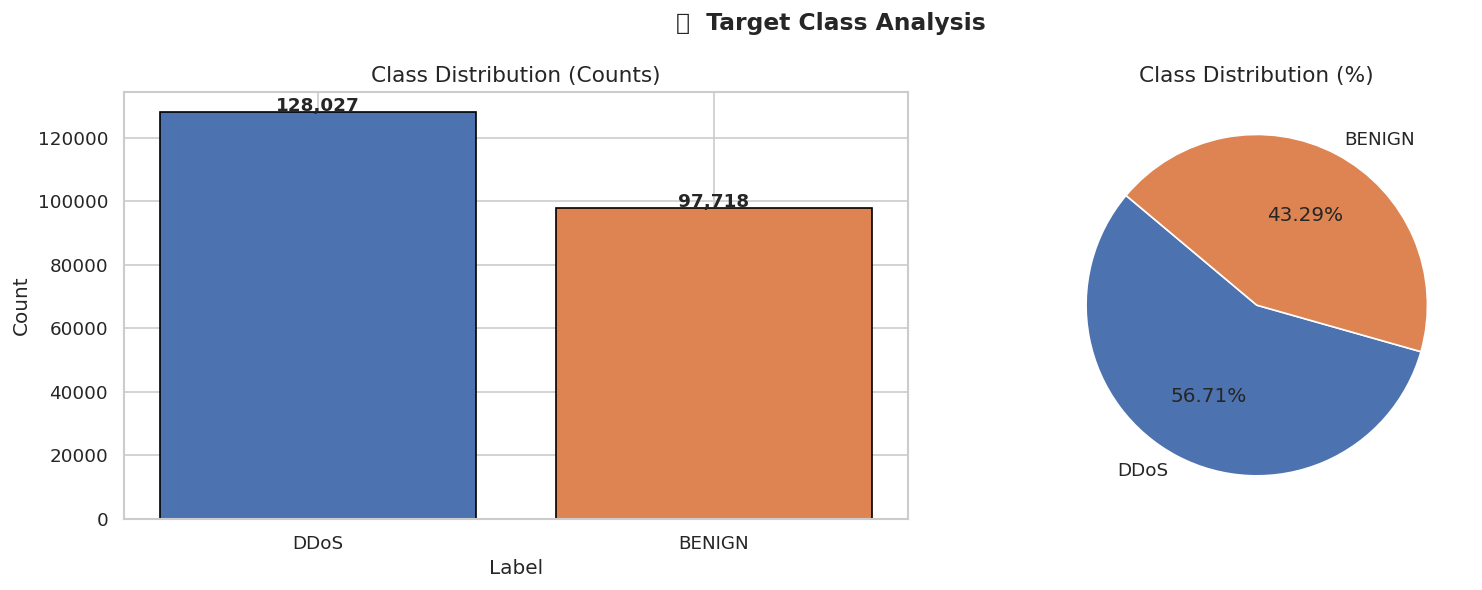

Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

📌 Numeric Features  : 80
                                     mean           std         min  \
Source Port                  3.825757e+04  2.305730e+04         0.0   
Destination Port             8.879619e+03  1.975465e+04         0.0   
Protocol                     7.600288e+00  3.881586e+00         0.0   
Flow Duration                1.624165e+07  3.152437e+07        -1.0   
Total Fwd Packets            4.874916e+00  1.542287e+01         1.0   
Total Backward Packets       4.572775e+00  2.175536e+01         0.0   
Total Length of Fwd Packets  9.394633e+02  3.249403e+03         0.0   
Total Length of Bwd Packets  5.960477e+03  3.921834e+04         0.0   
Fwd Packet Length Max        5.385357e+02  1.864129e+03         0.0   
Fwd Packet Length Min        2.788222e+01  1.633242e+02         0.0   
Fwd Packet Length Mean       1.648267e+02  5.048930e+02         0.0   
Fwd Packet Length Std        2.149072e+02  7.974111e+02 

In [5]:
df = df_raw.copy()

# ── 4.1 Class Distribution ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = df['Label'].value_counts()
axes[0].bar(class_counts.index, class_counts.values,
            color=['#4C72B0','#DD8452'], edgecolor='black')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f"{v:,}", ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Class Distribution (Counts)', fontsize=13)
axes[0].set_xlabel('Label'); axes[0].set_ylabel('Count')

axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct='%1.2f%%', startangle=140,
            colors=['#4C72B0','#DD8452'])
axes[1].set_title('Class Distribution (%)', fontsize=13)

plt.suptitle('🏷️  Target Class Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('01_class_distribution.png', bbox_inches='tight')
plt.show()
print(class_counts)

# ── 4.2 Numerical Feature Statistics ─────────────────────────
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\n📌 Numeric Features  : {len(num_cols)}")
print(df[num_cols].describe().T[['mean','std','min','max']].head(20))


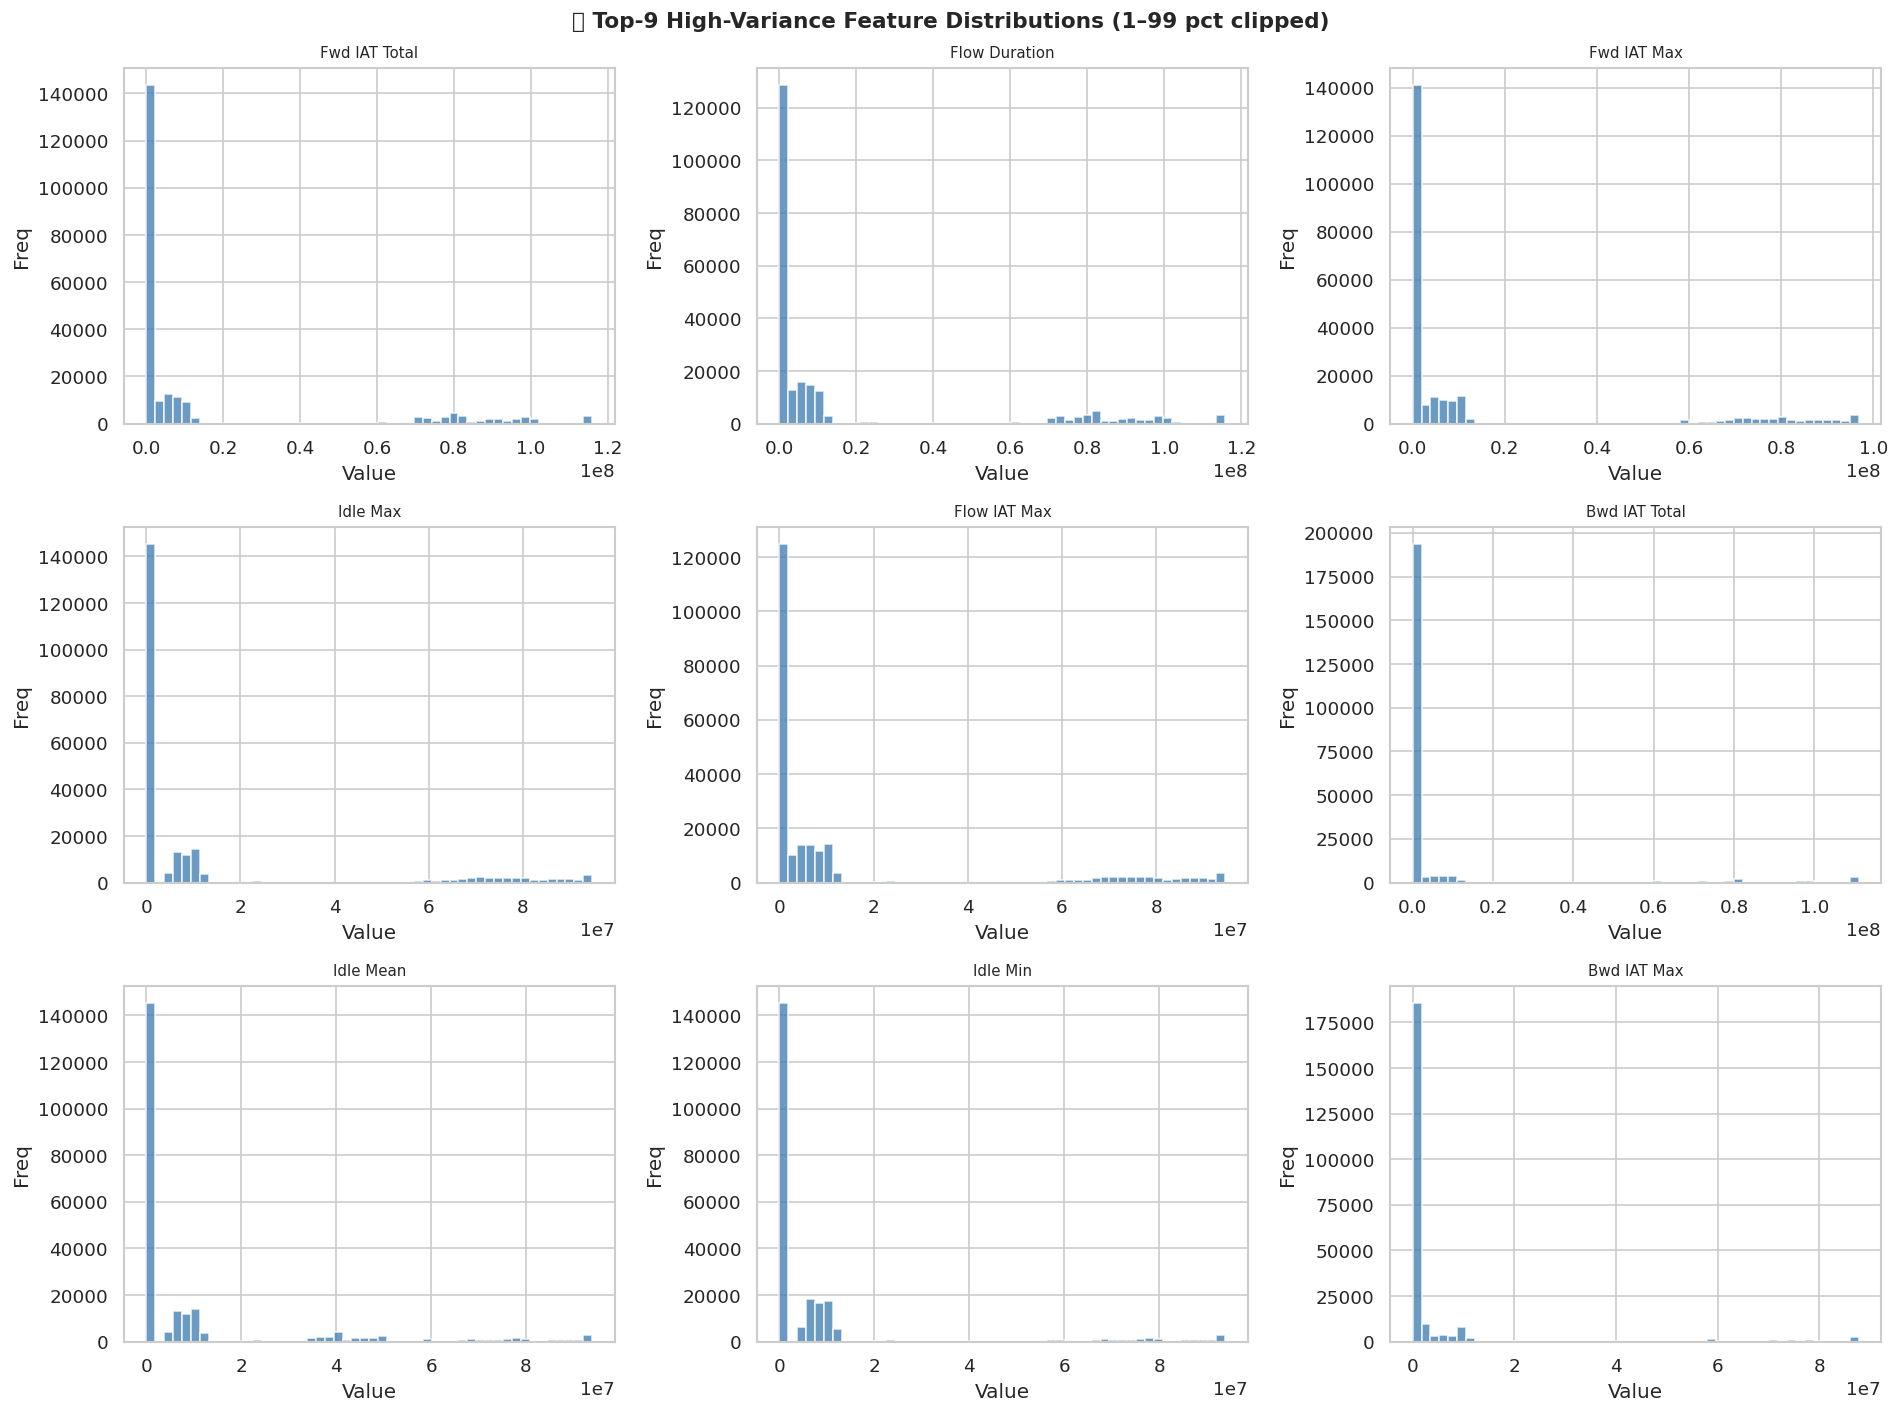

In [6]:
# ── 4.3 Distribution of Top Features by Variance ─────────────
top_var_cols = df[num_cols].var().nlargest(9).index.tolist()

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(top_var_cols):
    data = df[col].replace([np.inf, -np.inf], np.nan).dropna()
    data_clip = np.clip(data, data.quantile(0.01), data.quantile(0.99))
    axes[i].hist(data_clip, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col[:35], fontsize=9)
    axes[i].set_xlabel('Value'); axes[i].set_ylabel('Freq')
plt.suptitle('📈 Top-9 High-Variance Feature Distributions (1–99 pct clipped)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('02_feature_distributions.png', bbox_inches='tight')
plt.show()


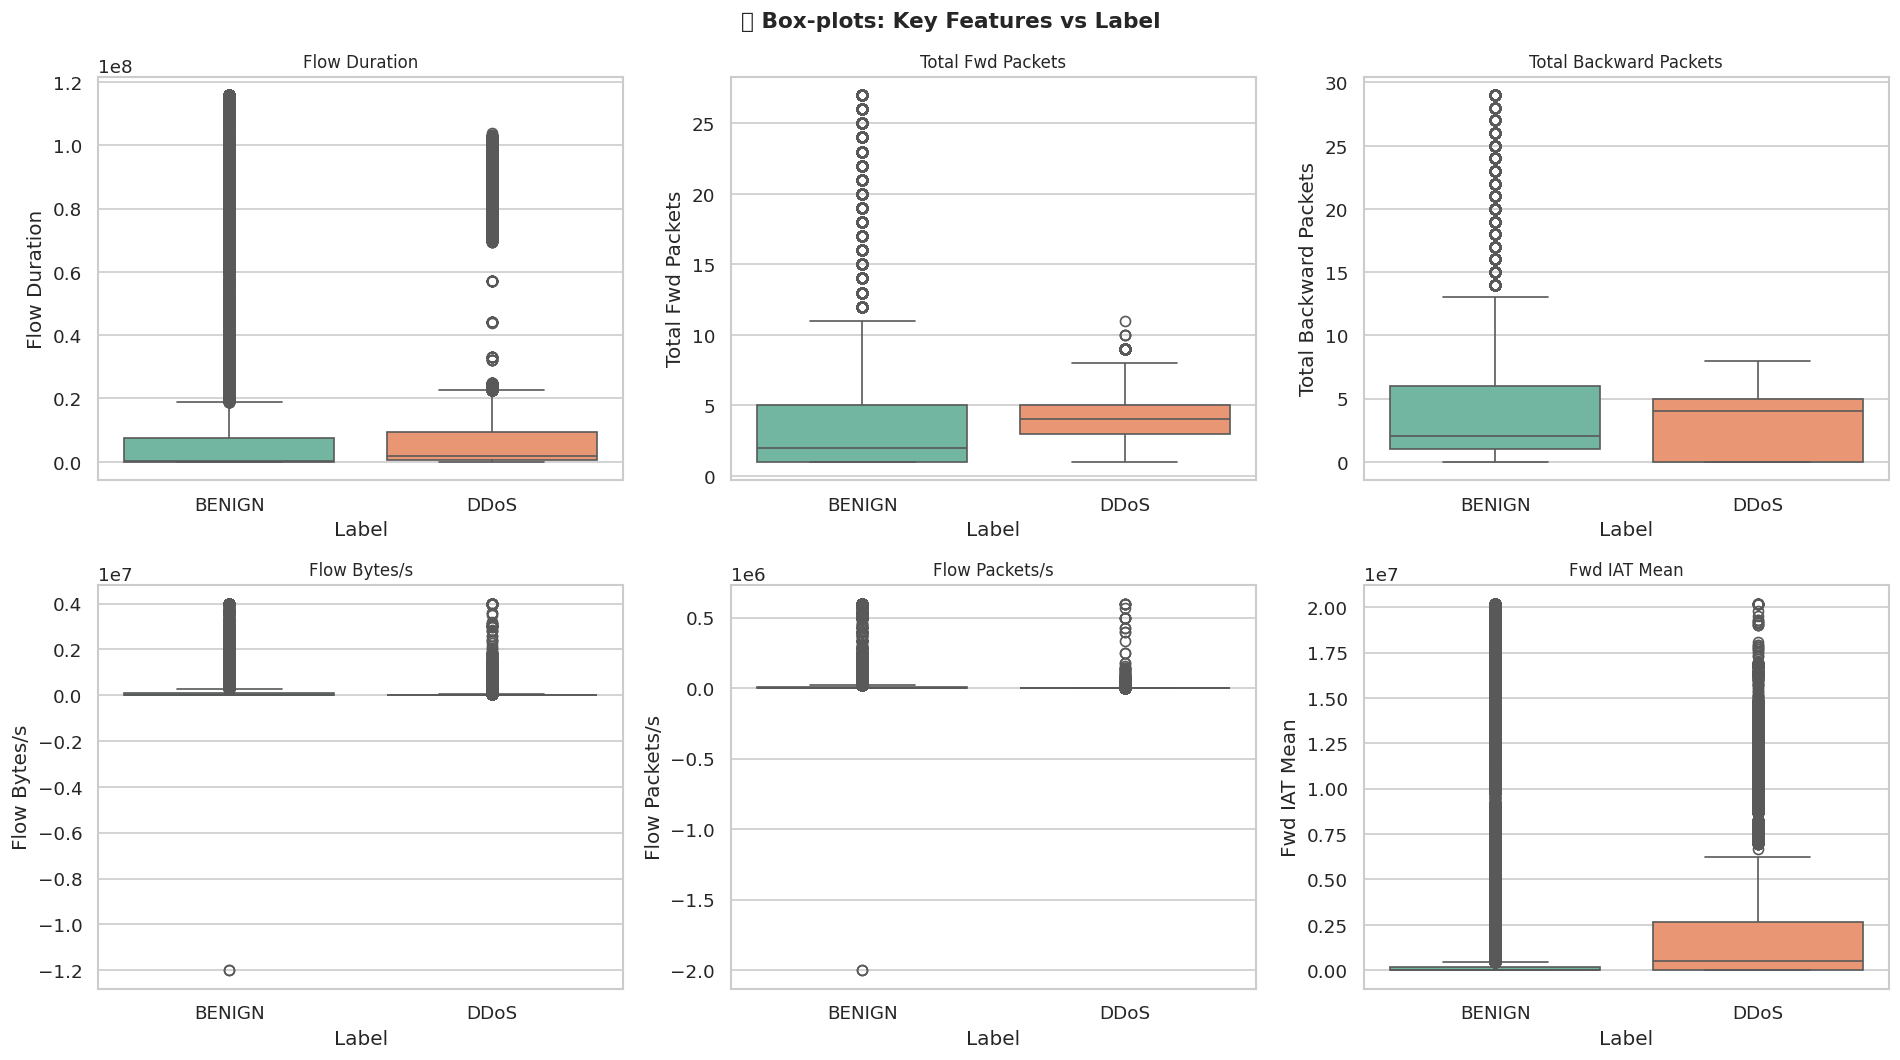

In [7]:
# ── 4.4 Box-plots per class for key features ─────────────────
key_feats = ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
             'Flow Bytes/s', 'Flow Packets/s', 'Fwd IAT Mean']
key_feats = [c for c in key_feats if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(key_feats):
    data = df[[col, 'Label']].copy()
    data[col] = data[col].replace([np.inf, -np.inf], np.nan)
    data.dropna(subset=[col], inplace=True)
    # clip outliers for visual clarity
    q99 = data[col].quantile(0.99)
    data[col] = data[col].clip(upper=q99)
    sns.boxplot(x='Label', y=col, data=data, ax=axes[i], palette='Set2')
    axes[i].set_title(col, fontsize=10)
plt.suptitle('📦 Box-plots: Key Features vs Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('03_boxplots_per_class.png', bbox_inches='tight')
plt.show()


## 🔧 Step 5: Data Preprocessing

In [8]:
# ── 5.1 Drop identifier columns & set X, y ───────────────────
id_cols = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']
drop_cols = [c for c in id_cols if c in df.columns]
df.drop(columns=drop_cols, inplace=True)

X = df.drop(columns=['Label'])
y = df['Label']

print(f"Features : {X.shape[1]}  |  Samples : {X.shape[0]:,}")

# ── 5.2 Data type enforcement ────────────────────────────────
X = X.apply(pd.to_numeric, errors='coerce')   # coerce any stray strings
print(f"Non-numeric cols after coerce: {X.select_dtypes(exclude=[np.number]).shape[1]}")

# ── 5.3 Replace Inf → NaN, then impute with median ──────────
X.replace([np.inf, -np.inf], np.nan, inplace=True)
missing_before = X.isnull().sum().sum()
X.fillna(X.median(numeric_only=True), inplace=True)
missing_after  = X.isnull().sum().sum()
print(f"\nMissing before imputation : {missing_before:,}")
print(f"Missing after  imputation : {missing_after}")

# ── 5.4 Duplicate rows ───────────────────────────────────────
dup_count = df.duplicated().sum()
print(f"\nDuplicate rows removed: {dup_count:,}")
df.drop_duplicates(inplace=True)
X = X.loc[df.index]
y = y.loc[df.index]

# ── 5.5 Encode target ─────────────────────────────────────────
le = LabelEncoder()
y_enc = le.fit_transform(y)
print(f"\nEncoded Classes: {dict(zip(le.classes_, range(len(le.classes_))))}")

print("\n✅ Preprocessing complete.")


Features : 80  |  Samples : 225,745
Non-numeric cols after coerce: 0

Missing before imputation : 68
Missing after  imputation : 0

Duplicate rows removed: 126

Encoded Classes: {'BENIGN': 0, 'DDoS': 1}

✅ Preprocessing complete.


## 🚨 Step 6: Outlier Detection & Handling

📌 Top 15 columns by IQR outlier count:
Destination Port               88668
Flow Bytes/s                   46323
Active Mean                    43734
Active Max                     43734
Active Min                     43646
Bwd Packets/s                  40908
Fwd Packets/s                  39728
Flow Packets/s                 39119
Flow Duration                  37464
Subflow Fwd Bytes              37408
Total Length of Fwd Packets    37408
Fwd IAT Total                  37265
Fwd Packet Length Min          36103
Fwd Header Length              35949
Fwd Header Length.1            35949


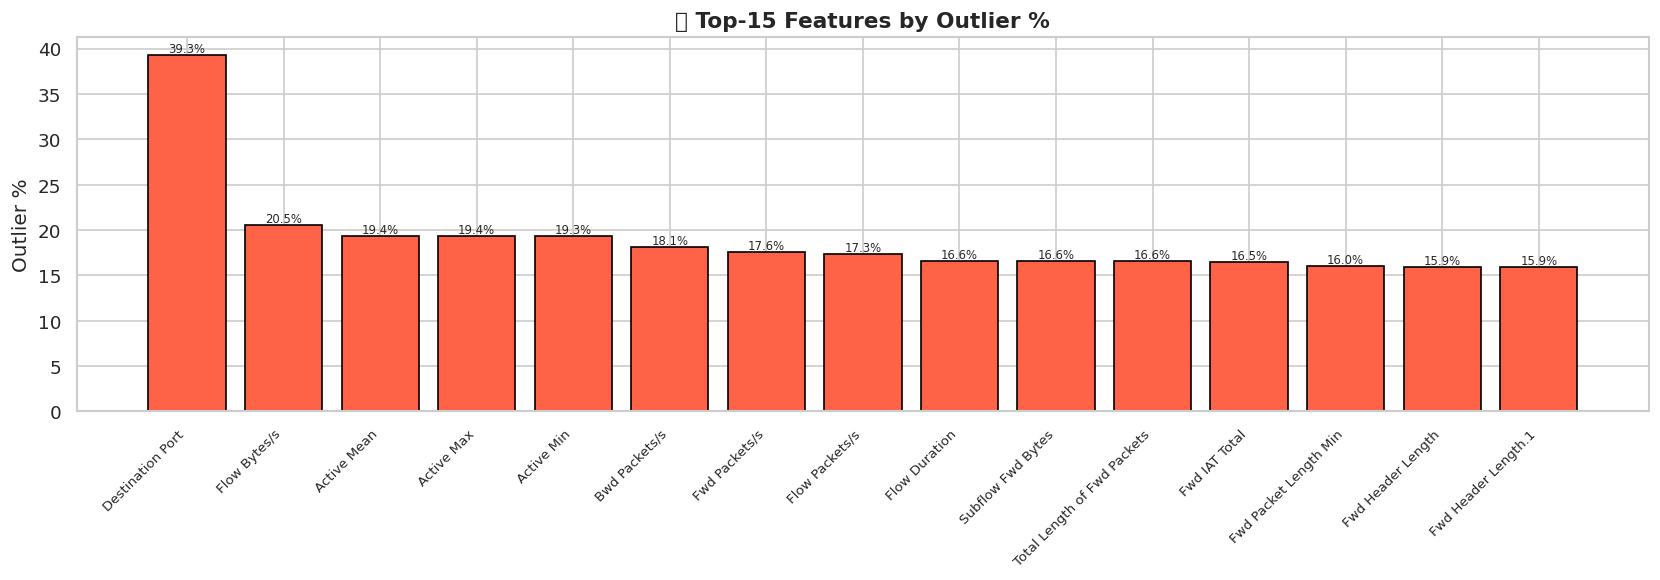


✅ Strategy: RobustScaler will be applied — preserves DDoS signal in outliers.


In [9]:
# ── IQR-based outlier count (informational) ──────────────────
def count_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()

outlier_counts = X.apply(count_outliers_iqr).sort_values(ascending=False)
print("📌 Top 15 columns by IQR outlier count:")
print(outlier_counts.head(15).to_string())

# ── Visualise outlier proportions ────────────────────────────
top15 = outlier_counts.head(15)
plt.figure(figsize=(14, 5))
bars = plt.bar(top15.index, top15.values / len(X) * 100,
               color='tomato', edgecolor='black')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.ylabel('Outlier %'); plt.title('📊 Top-15 Features by Outlier %', fontsize=13, fontweight='bold')
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
             f"{b.get_height():.1f}%", ha='center', fontsize=7)
plt.tight_layout()
plt.savefig('04_outlier_analysis.png', bbox_inches='tight')
plt.show()

# Strategy: Use RobustScaler (median-based) which is naturally outlier-resistant.
# We do NOT remove rows — network traffic outliers may be actual DDoS signals.
print("\n✅ Strategy: RobustScaler will be applied — preserves DDoS signal in outliers.")


## ⚖️ Step 7: Class Imbalance Analysis & Handling

📌 Class counts   : {'BENIGN': np.int64(97592), 'DDoS': np.int64(128027)}
📌 Imbalance ratio: 1.31

✅ Classes are relatively balanced (ratio < 1.5). SMOTE not required.


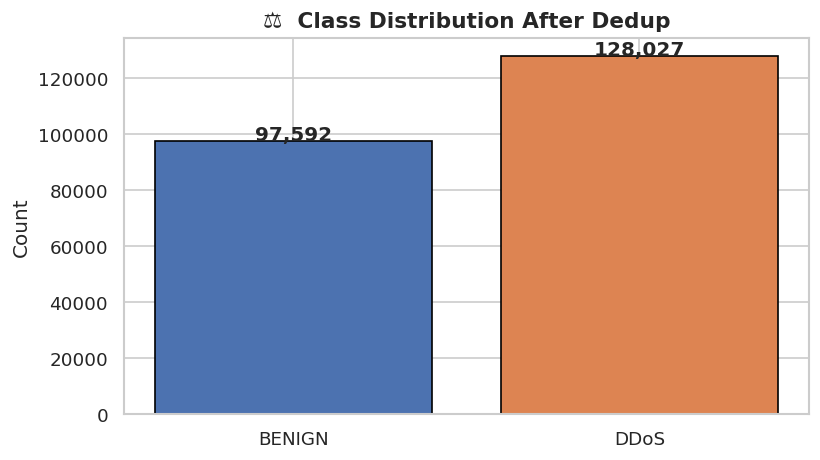

In [10]:
class_series = pd.Series(y_enc).value_counts().sort_index()
class_names  = le.classes_
imbalance_ratio = class_series.max() / class_series.min()
print(f"📌 Class counts   : {dict(zip(class_names, class_series.values))}")
print(f"📌 Imbalance ratio: {imbalance_ratio:.2f}")

if imbalance_ratio > 1.5:
    print("\n⚠️  Imbalance detected → SMOTE will be applied on training split.")
else:
    print("\n✅ Classes are relatively balanced (ratio < 1.5). SMOTE not required.")

# Visual
plt.figure(figsize=(7, 4))
plt.bar(class_names, class_series.values, color=['#4C72B0','#DD8452'], edgecolor='black')
for i, v in enumerate(class_series.values):
    plt.text(i, v + 200, f"{v:,}", ha='center', fontweight='bold')
plt.title('⚖️  Class Distribution After Dedup', fontsize=13, fontweight='bold')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('05_class_imbalance.png', bbox_inches='tight')
plt.show()


## 🎯 Step 8: Feature Selection

Zero-variance features removed: 10 → ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']

Computing correlation matrix...
Highly correlated features (>0.97) removed: 22

📌 Features after correlation pruning: 48

Computing Mutual Information scores (using 50k sample for speed)...


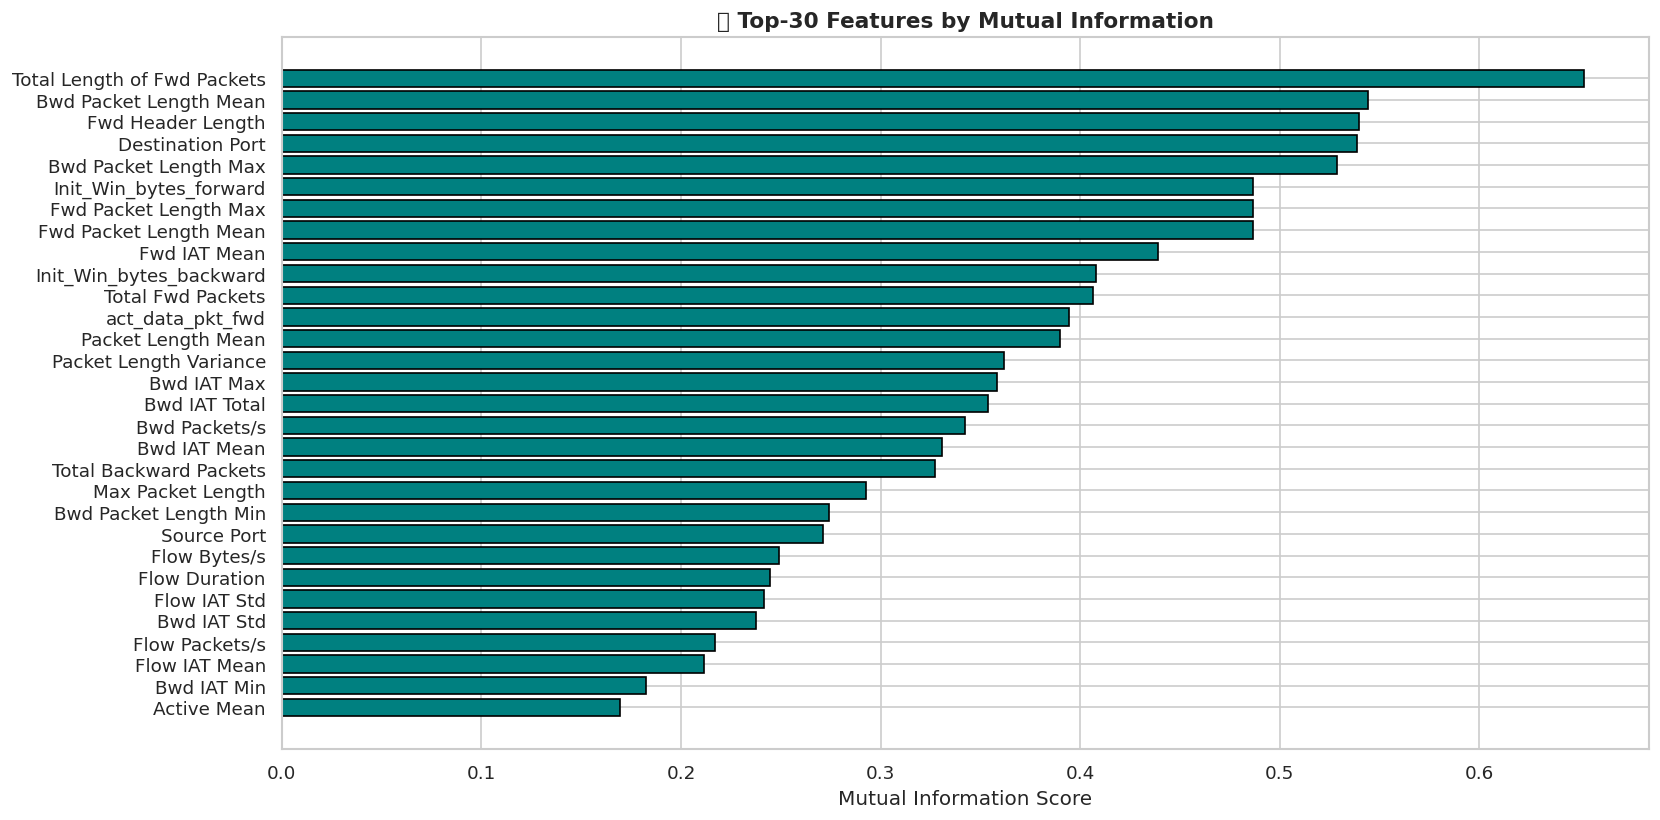


✅ Final selected features (30): ['Total Length of Fwd Packets', 'Bwd Packet Length Mean', 'Fwd Header Length', 'Destination Port', 'Bwd Packet Length Max', 'Init_Win_bytes_forward', 'Fwd Packet Length Max', 'Fwd Packet Length Mean', 'Fwd IAT Mean', 'Init_Win_bytes_backward', 'Total Fwd Packets', 'act_data_pkt_fwd', 'Packet Length Mean', 'Packet Length Variance', 'Bwd IAT Max', 'Bwd IAT Total', 'Bwd Packets/s', 'Bwd IAT Mean', 'Total Backward Packets', 'Max Packet Length', 'Bwd Packet Length Min', 'Source Port', 'Flow Bytes/s', 'Flow Duration', 'Flow IAT Std', 'Bwd IAT Std', 'Flow Packets/s', 'Flow IAT Mean', 'Bwd IAT Min', 'Active Mean']


In [11]:
# ── 8.1 Remove zero-variance features ────────────────────────
zero_var = X.columns[X.var() == 0].tolist()
print(f"Zero-variance features removed: {len(zero_var)} → {zero_var}")
X.drop(columns=zero_var, inplace=True)

# ── 8.2 Remove near-duplicate / highly correlated features ──
print("\nComputing correlation matrix...")
corr_matrix = X.corr().abs()
upper       = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr   = [col for col in upper.columns if any(upper[col] > 0.97)]
print(f"Highly correlated features (>0.97) removed: {len(high_corr)}")
X.drop(columns=high_corr, inplace=True)

print(f"\n📌 Features after correlation pruning: {X.shape[1]}")

# ── 8.3 Mutual Information Scores ────────────────────────────
print("\nComputing Mutual Information scores (using 50k sample for speed)...")
sample_idx = np.random.choice(len(X), size=min(50000, len(X)), replace=False)
mi_scores  = mutual_info_classif(X.iloc[sample_idx], y_enc[sample_idx], random_state=42)
mi_series  = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

top30_mi = mi_series.head(30)
plt.figure(figsize=(14, 7))
bars = plt.barh(top30_mi.index[::-1], top30_mi.values[::-1], color='teal', edgecolor='black')
plt.xlabel('Mutual Information Score')
plt.title('🎯 Top-30 Features by Mutual Information', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('06_mutual_information.png', bbox_inches='tight')
plt.show()

# ── 8.4 Select Top-N features ───────────────────────────────
TOP_N = 30
selected_features = mi_series.head(TOP_N).index.tolist()
X_sel = X[selected_features]
print(f"\n✅ Final selected features ({TOP_N}): {selected_features}")


## 🔥 Step 9: Correlation Heatmap of Selected Features

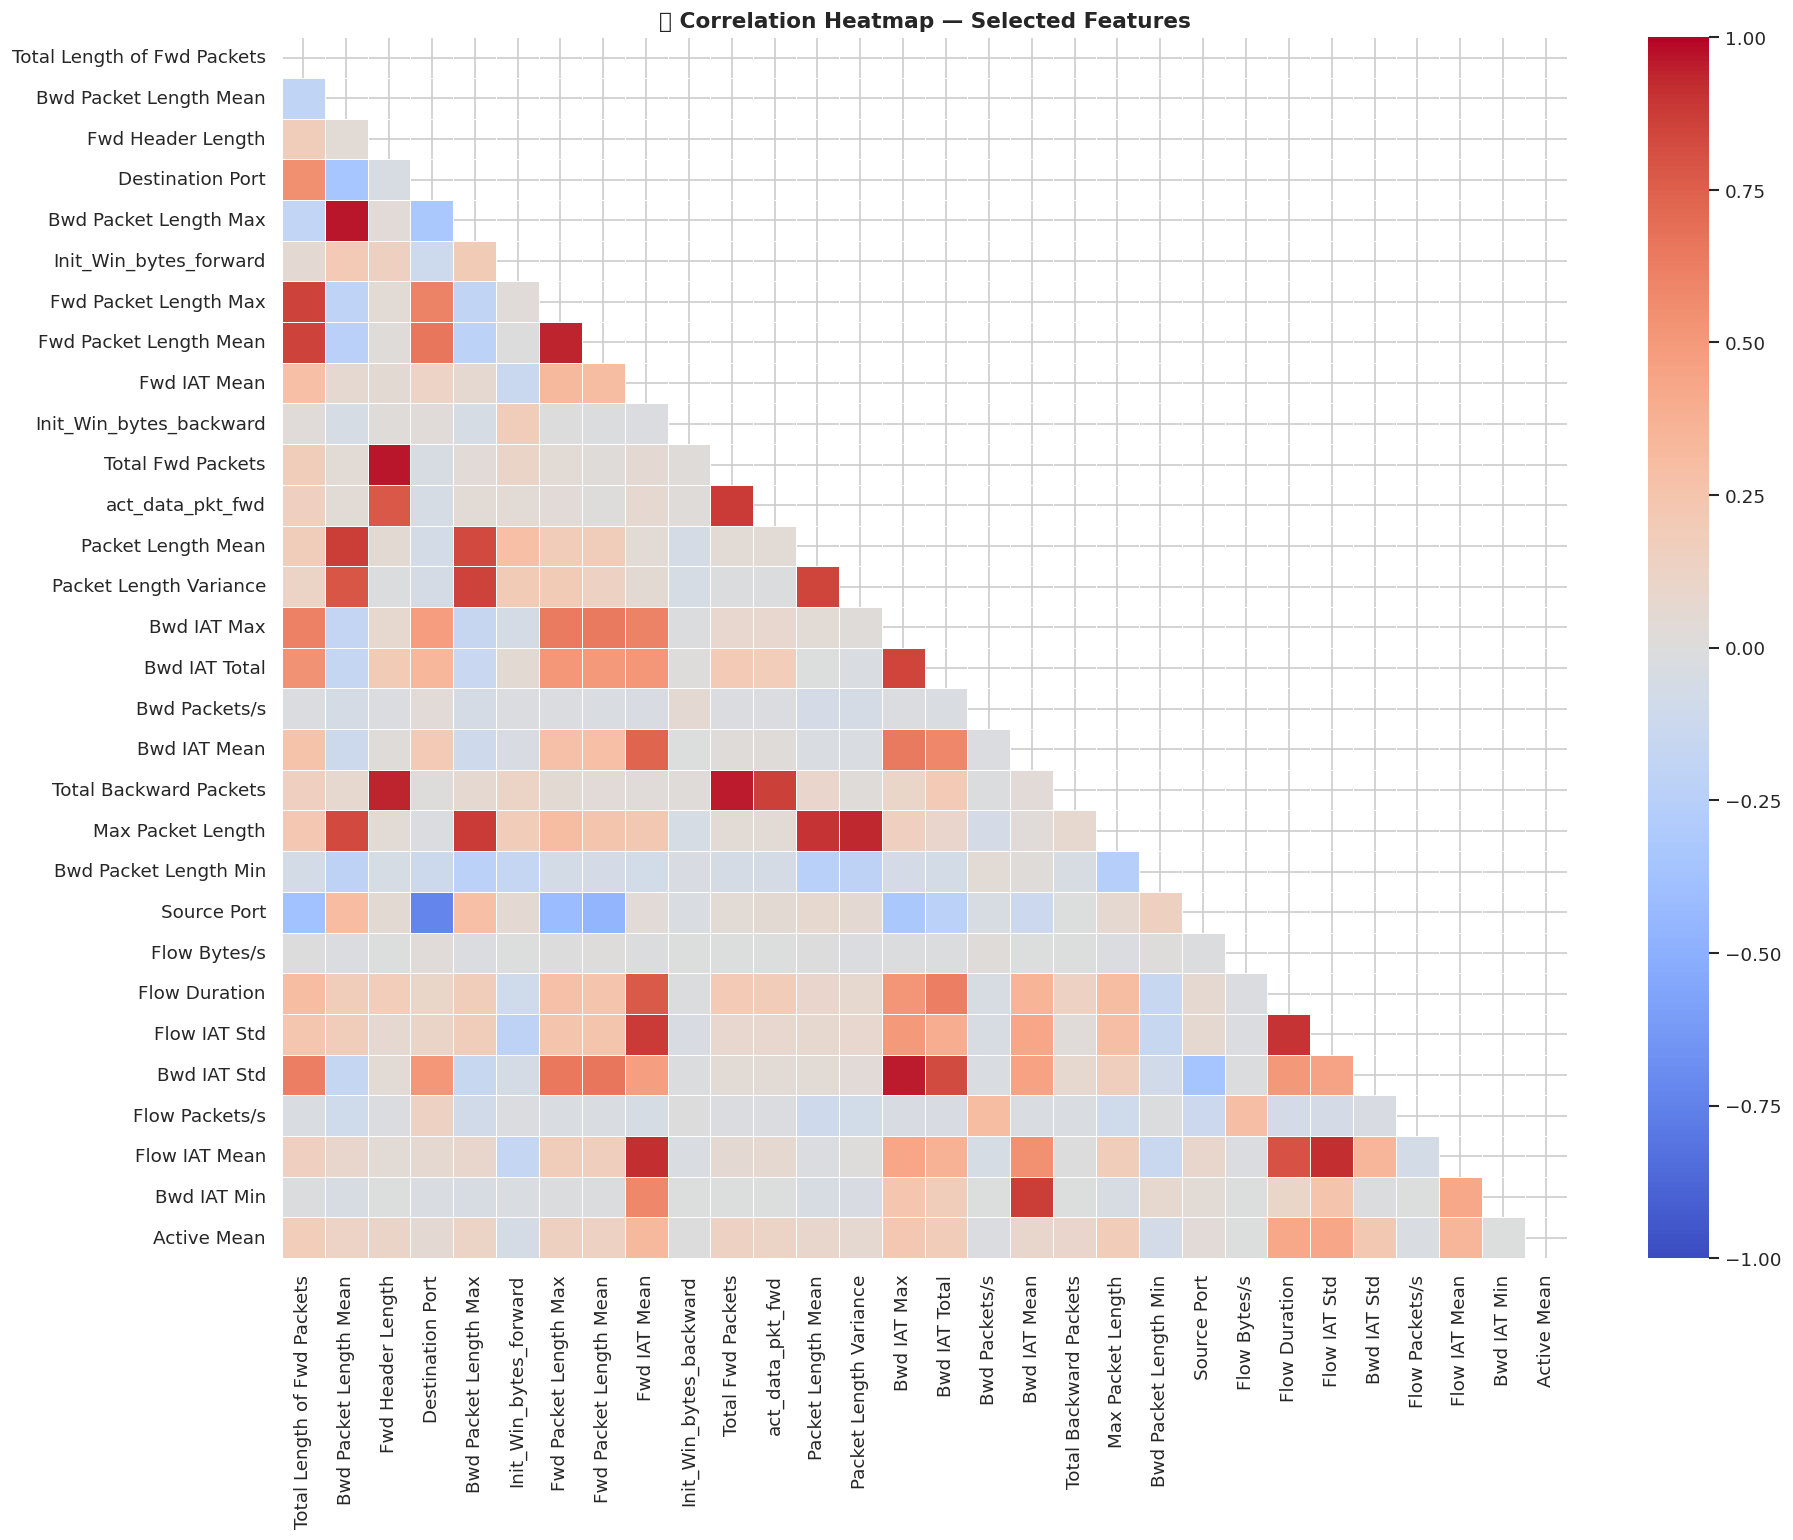

In [12]:
plt.figure(figsize=(16, 13))
corr_sel = X_sel.corr()
mask = np.triu(np.ones_like(corr_sel, dtype=bool))
sns.heatmap(corr_sel, mask=mask, annot=False, cmap='coolwarm',
            linewidths=0.3, vmin=-1, vmax=1)
plt.title('🔥 Correlation Heatmap — Selected Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('07_correlation_heatmap.png', bbox_inches='tight')
plt.show()


## ✂️ Step 10: Train / Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

print(f"Train set : {X_train.shape[0]:,} samples")
print(f"Test  set : {X_test.shape[0]:,} samples")
print(f"Train class dist: {dict(zip(le.classes_, np.bincount(y_train)))}")
print(f"Test  class dist: {dict(zip(le.classes_, np.bincount(y_test)))}")

# ── Scaling (RobustScaler for outlier robustness) ─────────────
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("\n✅ RobustScaler applied.")

# ── SMOTE on training data (conditional) ─────────────────────
if imbalance_ratio > 1.5:
    smote = SMOTE(random_state=42)
    X_train_sc, y_train = smote.fit_resample(X_train_sc, y_train)
    print(f"After SMOTE — Train class dist: {dict(zip(le.classes_, np.bincount(y_train)))}")
else:
    print("No SMOTE needed.")


Train set : 180,495 samples
Test  set : 45,124 samples
Train class dist: {'BENIGN': np.int64(78074), 'DDoS': np.int64(102421)}
Test  class dist: {'BENIGN': np.int64(19518), 'DDoS': np.int64(25606)}

✅ RobustScaler applied.
No SMOTE needed.


## 🔄 Step 11: Stratified K-Fold Cross-Validation

Random Forest        | CV F1 (macro): 0.9999 ± 0.0000
XGBoost              | CV F1 (macro): 0.9999 ± 0.0000


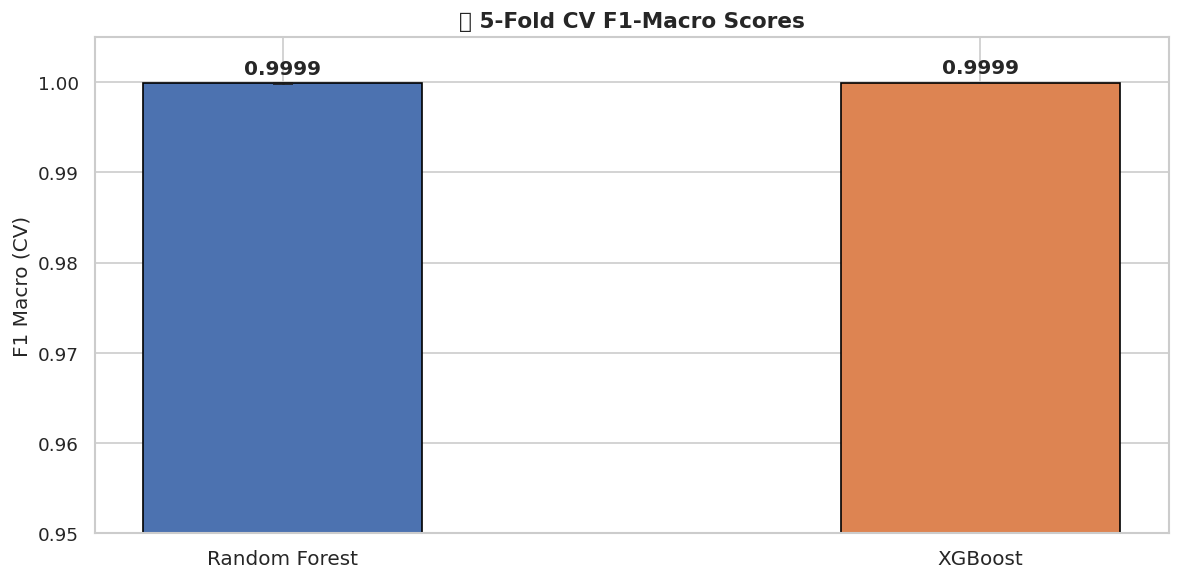

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost'       : XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                                    random_state=42, eval_metric='logloss', use_label_encoder=False),
}

cv_results = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:20s} | CV F1 (macro): {scores.mean():.4f} ± {scores.std():.4f}")

# Plot CV results
fig, ax = plt.subplots(figsize=(10, 5))
positions = np.arange(len(cv_results))
for i, (name, scores) in enumerate(cv_results.items()):
    ax.bar(i, scores.mean(), yerr=scores.std(), capsize=6,
           color=['#4C72B0','#DD8452'][i], edgecolor='black', width=0.4)
    ax.text(i, scores.mean() + scores.std() + 0.001, f"{scores.mean():.4f}", ha='center', fontweight='bold')
ax.set_xticks(positions); ax.set_xticklabels(list(cv_results.keys()), fontsize=12)
ax.set_ylabel('F1 Macro (CV)'); ax.set_ylim(0.95, 1.005)
ax.set_title('🔄 5-Fold CV F1-Macro Scores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('08_cross_validation.png', bbox_inches='tight')
plt.show()


## 🔬 Step 12: Hyperparameter Tuning with GridSearchCV

In [15]:
# ── 12.1 XGBoost GridSearchCV ──────────────────────────────
print("🔬 GridSearchCV for XGBoost (may take a few minutes)...")

xgb_param_grid = {
    'n_estimators' : [100, 200],
    'max_depth'    : [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample'    : [0.8, 1.0],
}

xgb_gs = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False),
    xgb_param_grid, cv=3, scoring='f1_macro', n_jobs=-1, verbose=1
)
xgb_gs.fit(X_train_sc, y_train)
print(f"\n✅ XGBoost Best Params : {xgb_gs.best_params_}")
print(f"   Best CV F1-Macro    : {xgb_gs.best_score_:.4f}")

# ── 12.2 Random Forest GridSearchCV ──────────────────────────
print("\n🔬 GridSearchCV for Random Forest...")

rf_param_grid = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [None, 20],
    'min_samples_split': [2, 5],
}

rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid, cv=3, scoring='f1_macro', n_jobs=-1, verbose=1
)
rf_gs.fit(X_train_sc, y_train)
print(f"\n✅ Random Forest Best Params : {rf_gs.best_params_}")
print(f"   Best CV F1-Macro          : {rf_gs.best_score_:.4f}")


🔬 GridSearchCV for XGBoost (may take a few minutes)...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

✅ XGBoost Best Params : {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
   Best CV F1-Macro    : 1.0000

🔬 GridSearchCV for Random Forest...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

✅ Random Forest Best Params : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
   Best CV F1-Macro          : 0.9999


## 🤖 Step 13: Model Training — RF, SVM, XGBoost

1.   List item
2.   List item



In [16]:
results = {}

# ── 13.1 XGBoost (best from GridSearch) ──────────────────────
print("Training XGBoost...")
xgb_best = xgb_gs.best_estimator_
xgb_best.fit(X_train_sc, y_train)
y_pred_xgb  = xgb_best.predict(X_test_sc)
y_prob_xgb  = xgb_best.predict_proba(X_test_sc)[:, 1]
results['XGBoost'] = {'pred': y_pred_xgb, 'prob': y_prob_xgb}
print(f"  XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")

# ── 13.2 Random Forest (best from GridSearch) ────────────────
print("Training Random Forest...")
rf_best = rf_gs.best_estimator_
rf_best.fit(X_train_sc, y_train)
y_pred_rf  = rf_best.predict(X_test_sc)
y_prob_rf  = rf_best.predict_proba(X_test_sc)[:, 1]
results['Random Forest'] = {'pred': y_pred_rf, 'prob': y_prob_rf}
print(f"  Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

# ── 13.3 SVM (on a 20k sample for speed, then full inference) ─
print("Training SVM (sample-based)...")
sample_size = min(20000, len(X_train_sc))
idx = np.random.RandomState(42).choice(len(X_train_sc), sample_size, replace=False)
svm_model = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train_sc[idx], y_train[idx])
y_pred_svm = svm_model.predict(X_test_sc)
y_prob_svm = svm_model.predict_proba(X_test_sc)[:, 1]
results['SVM'] = {'pred': y_pred_svm, 'prob': y_prob_svm}
print(f"  SVM Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")

print("\n✅ All models trained.")


Training XGBoost...
  XGBoost Accuracy: 1.0000
Training Random Forest...
  Random Forest Accuracy: 1.0000
Training SVM (sample-based)...
  SVM Accuracy: 0.8023

✅ All models trained.


## 📈 Step 14: Evaluation Metrics & Classification Reports

In [17]:
def get_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy'  : accuracy_score(y_true, y_pred),
        'F1-Macro'  : f1_score(y_true, y_pred, average='macro'),
        'F1-Weighted': f1_score(y_true, y_pred, average='weighted'),
        'ROC-AUC'   : roc_auc_score(y_true, y_prob),
    }

metrics_rows = []
for name, res in results.items():
    m = get_metrics(y_test, res['pred'], res['prob'])
    m['Model'] = name
    metrics_rows.append(m)
    print(f"\n{'─'*55}")
    print(f"  📊 {name}")
    print(f"{'─'*55}")
    print(classification_report(y_test, res['pred'], target_names=le.classes_))

metrics_df = pd.DataFrame(metrics_rows).set_index('Model')
print("\n" + "="*55)
print("  📋 SUMMARY TABLE")
print("="*55)
print(metrics_df.round(4).to_string())
metrics_df.to_csv('model_metrics_summary.csv')



───────────────────────────────────────────────────────
  📊 XGBoost
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19518
        DDoS       1.00      1.00      1.00     25606

    accuracy                           1.00     45124
   macro avg       1.00      1.00      1.00     45124
weighted avg       1.00      1.00      1.00     45124


───────────────────────────────────────────────────────
  📊 Random Forest
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19518
        DDoS       1.00      1.00      1.00     25606

    accuracy                           1.00     45124
   macro avg       1.00      1.00      1.00     45124
weighted avg       1.00      1.00      1.00     45124


───────────────────────────────────────────────────────
  📊 SVM
─────────────────────────

## 🟦 Step 15: Confusion Matrices

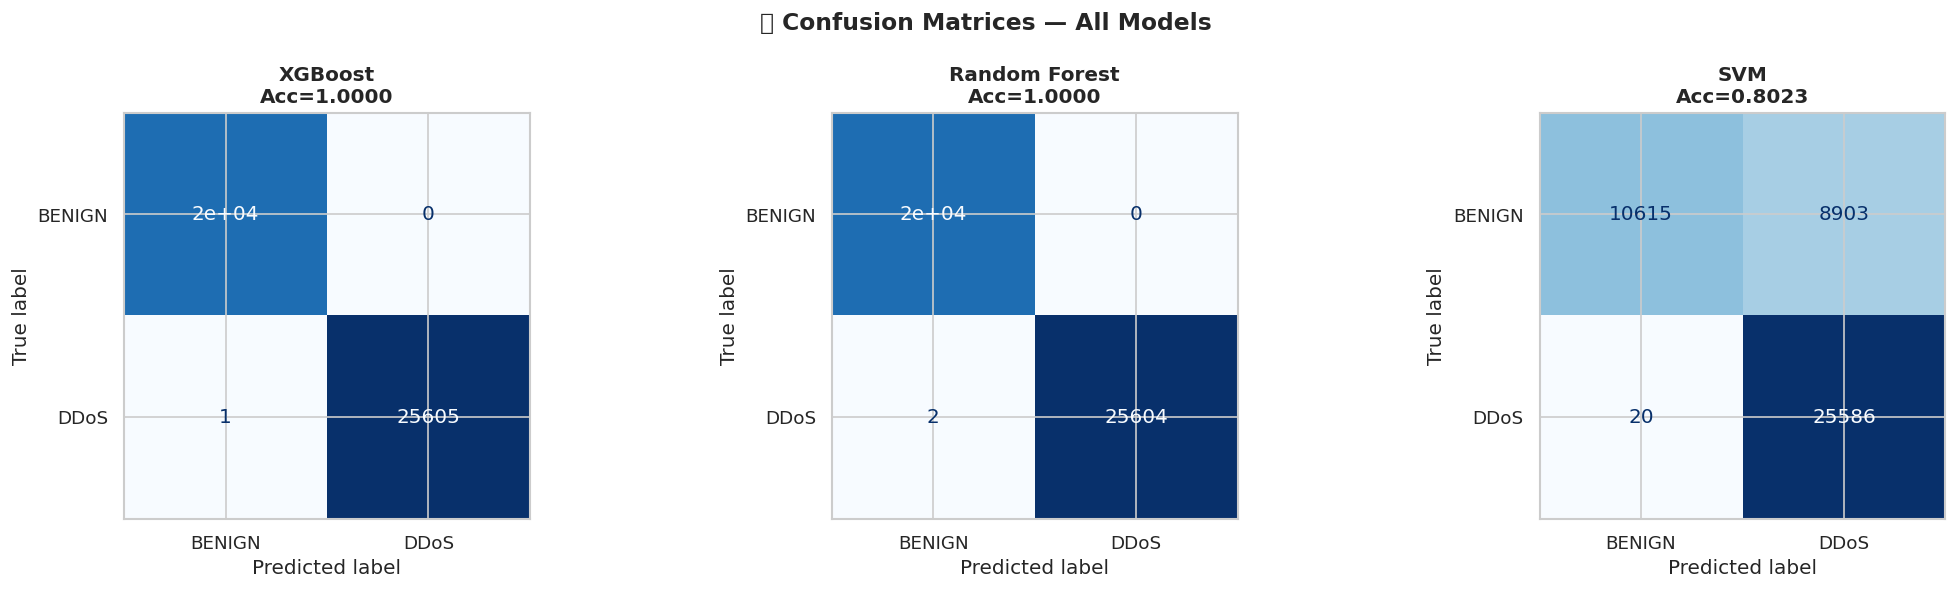

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    acc = accuracy_score(y_test, res['pred'])
    ax.set_title(f'{name}\nAcc={acc:.4f}', fontsize=12, fontweight='bold')

plt.suptitle('🟦 Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('09_confusion_matrices.png', bbox_inches='tight')
plt.show()


## 📉 Step 16: ROC Curves

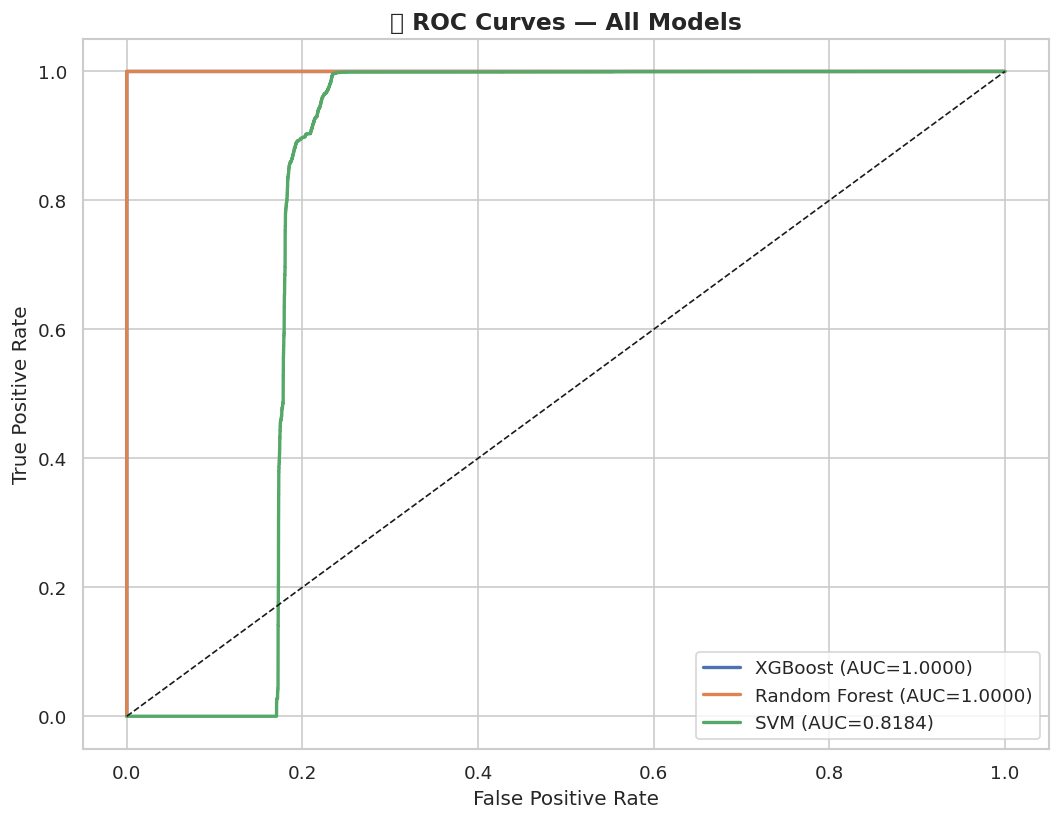

In [19]:
plt.figure(figsize=(9, 7))
colors = ['#4C72B0', '#DD8452', '#55A868']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    auc_val = roc_auc_score(y_test, res['prob'])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.4f})', color=color, linewidth=2)

plt.plot([0,1],[0,1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate',  fontsize=12)
plt.title('📉 ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('10_roc_curves.png', bbox_inches='tight')
plt.show()


## 🎯 Step 17: Precision-Recall Curves

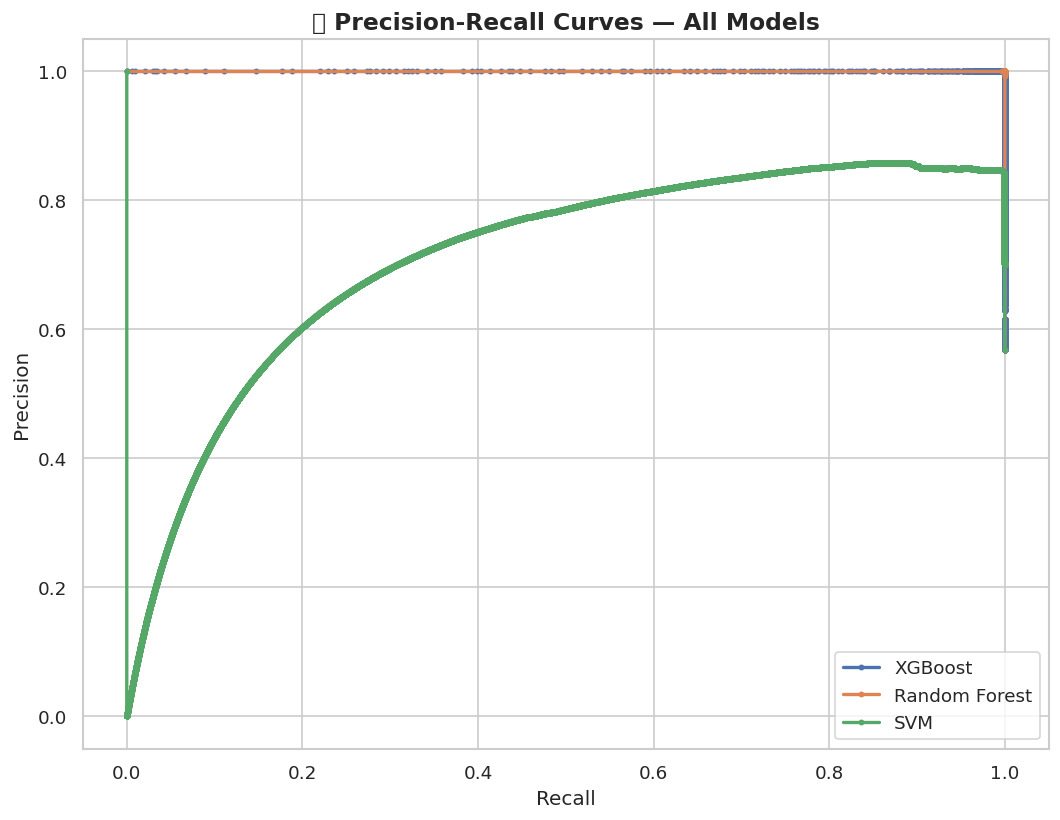

In [26]:
plt.figure(figsize=(9, 7))

for (name, res), color in zip(results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, res['prob'])
    plt.plot(rec, prec, label=name, color=color, linewidth=2)

plt.xlabel('Recall',    fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('🎯 Precision-Recall Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('11_precision_recall_curves.png', bbox_inches='tight')
plt.show()


## 📊 Step 18: Model Comparison Bar Chart

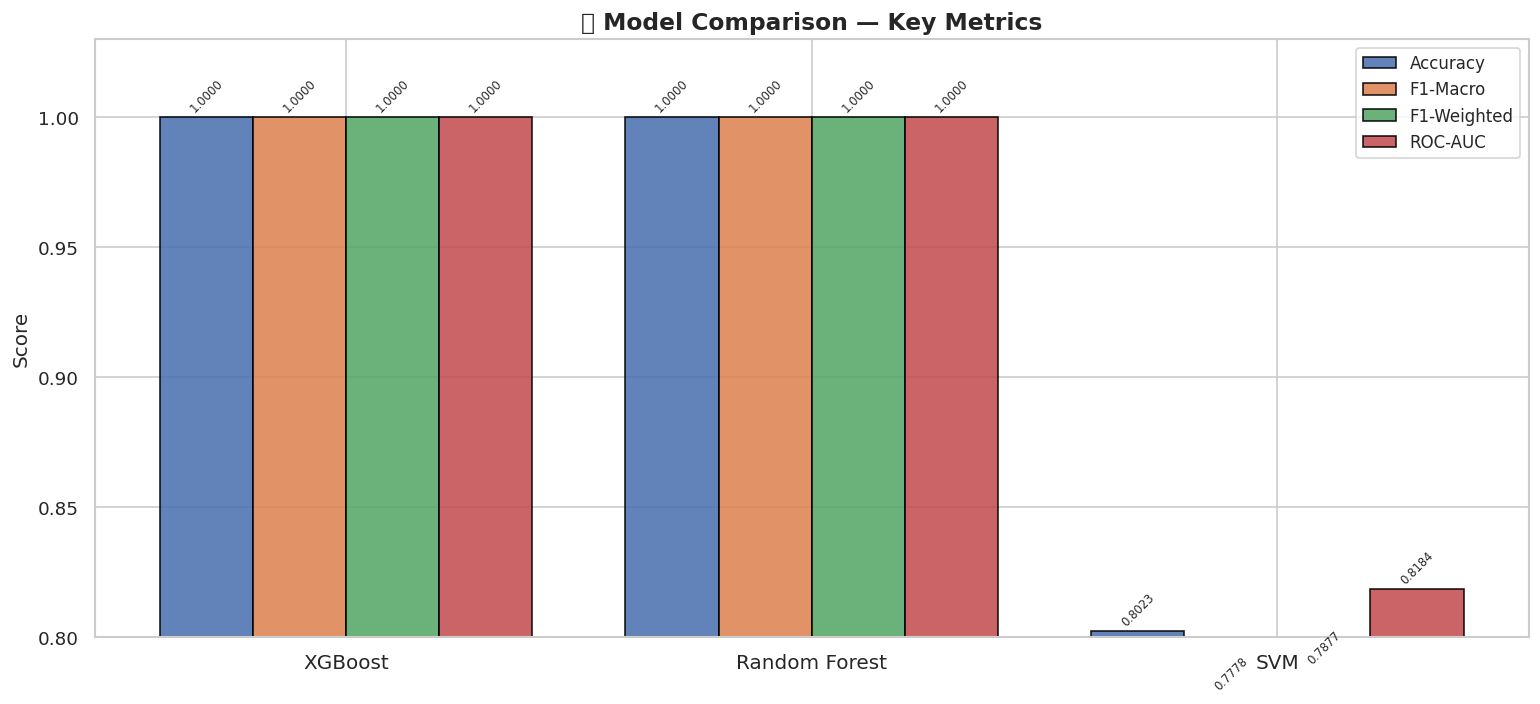

In [21]:
metrics_df_reset = metrics_df.reset_index()
metrics_to_plot  = ['Accuracy', 'F1-Macro', 'F1-Weighted', 'ROC-AUC']

x    = np.arange(len(metrics_df))
width = 0.2
fig, ax = plt.subplots(figsize=(13, 6))
palette = ['#4C72B0','#DD8452','#55A868','#C44E52']

for i, (metric, color) in enumerate(zip(metrics_to_plot, palette)):
    bars = ax.bar(x + i*width, metrics_df[metric], width, label=metric,
                  color=color, edgecolor='black', alpha=0.88)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.001,
                f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(metrics_df.index, fontsize=12)
ax.set_ylim(0.8, 1.03)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('📊 Model Comparison — Key Metrics', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('12_model_comparison_bar.png', bbox_inches='tight')
plt.show()


## 🏆 Step 19: Feature Importance (XGBoost & Random Forest)

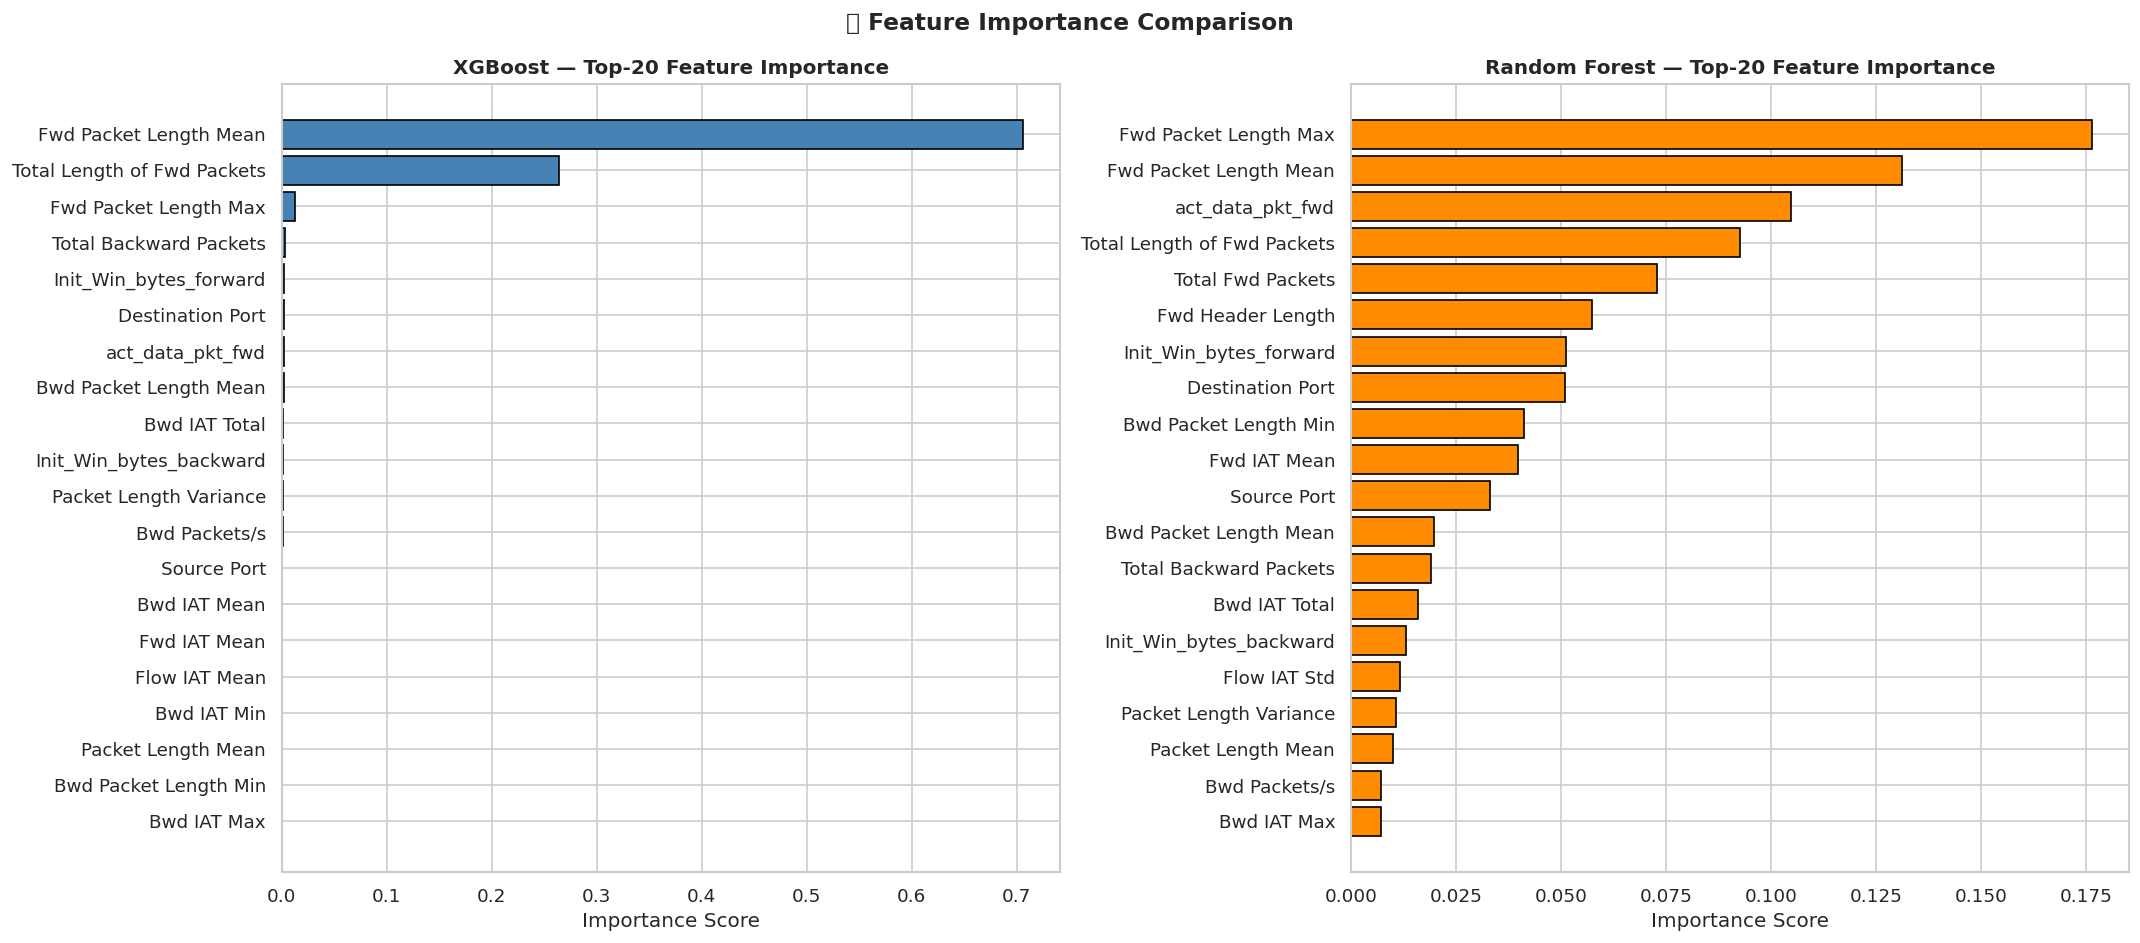

✅ Feature importance saved to feature_importance.csv


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# XGBoost
xgb_imp = pd.Series(xgb_best.feature_importances_, index=X_sel.columns).sort_values(ascending=False).head(20)
axes[0].barh(xgb_imp.index[::-1], xgb_imp.values[::-1], color='steelblue', edgecolor='black')
axes[0].set_title('XGBoost — Top-20 Feature Importance', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance Score')

# Random Forest
rf_imp = pd.Series(rf_best.feature_importances_, index=X_sel.columns).sort_values(ascending=False).head(20)
axes[1].barh(rf_imp.index[::-1], rf_imp.values[::-1], color='darkorange', edgecolor='black')
axes[1].set_title('Random Forest — Top-20 Feature Importance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.suptitle('🏆 Feature Importance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('13_feature_importance.png', bbox_inches='tight')
plt.show()

# Save feature importance to CSV
fi_df = pd.DataFrame({'XGBoost': xgb_imp, 'Random Forest': rf_imp})
fi_df.to_csv('feature_importance.csv')
print("✅ Feature importance saved to feature_importance.csv")


## 📈 Step 20: Learning Curves (XGBoost)

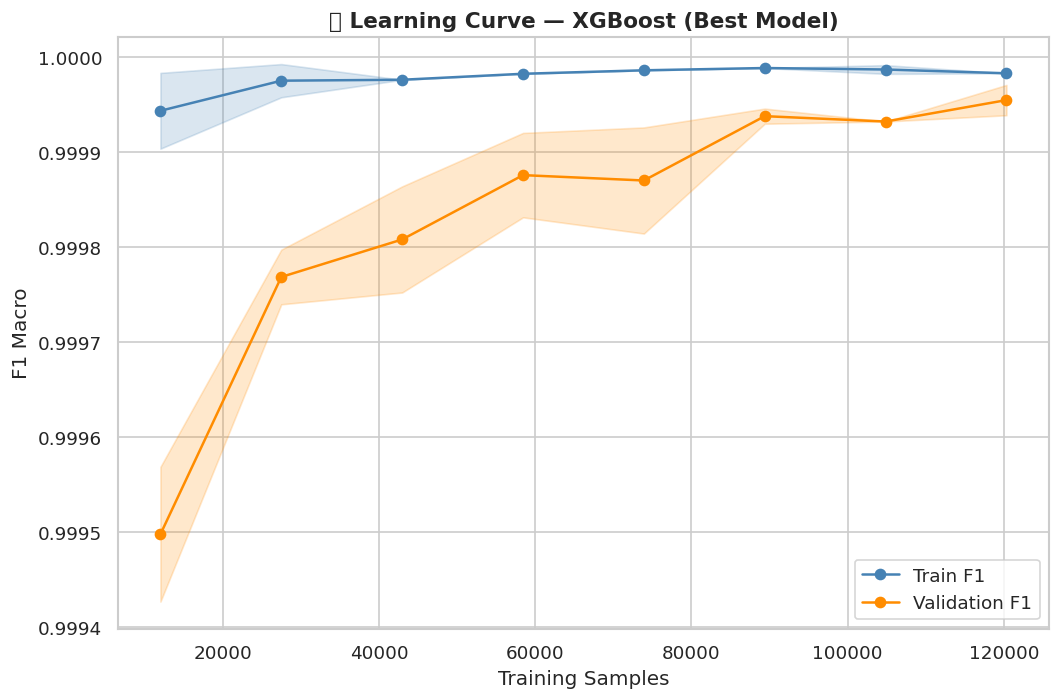

In [23]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    XGBClassifier(**xgb_gs.best_params_, random_state=42,
                  eval_metric='logloss', use_label_encoder=False),
    X_train_sc, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=3, scoring='f1_macro', n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(9, 6))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train F1')
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.2, color='steelblue')
plt.plot(train_sizes, val_mean, 'o-', color='darkorange', label='Validation F1')
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.2, color='darkorange')
plt.xlabel('Training Samples', fontsize=12)
plt.ylabel('F1 Macro',          fontsize=12)
plt.title('📈 Learning Curve — XGBoost (Best Model)', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('14_learning_curve.png', bbox_inches='tight')
plt.show()


## 📈 Step 20.1: Learning Curves (Random Forest)

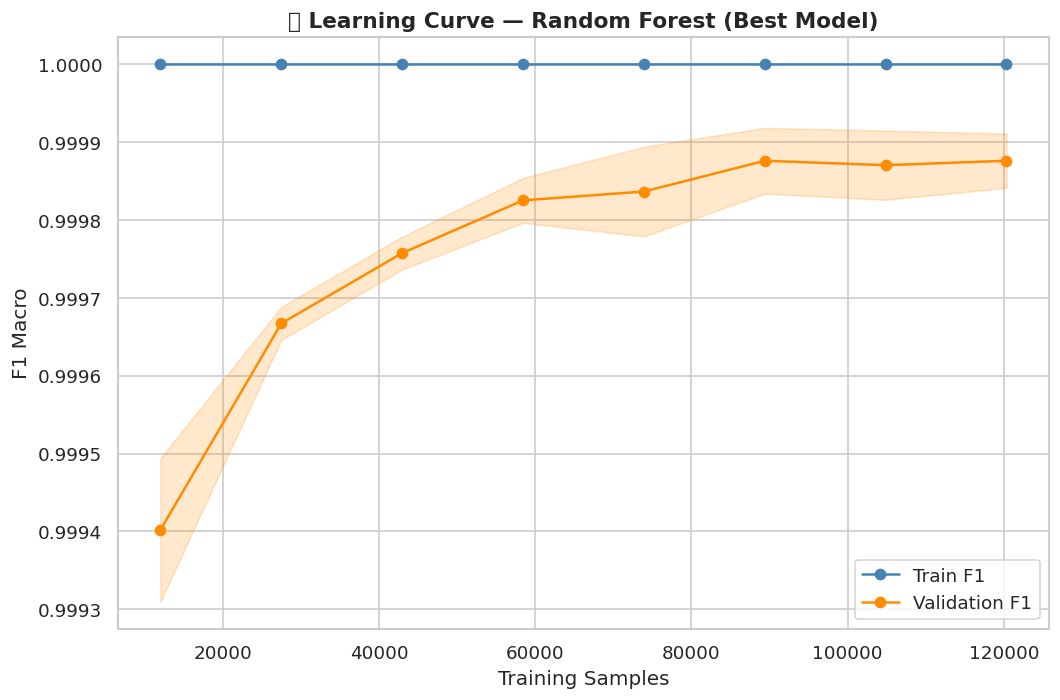

In [27]:
from sklearn.model_selection import learning_curve

train_sizes_rf, train_scores_rf, val_scores_rf = learning_curve(
    RandomForestClassifier(**rf_gs.best_params_, random_state=42, n_jobs=-1),
    X_train_sc, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=3, scoring='f1_macro', n_jobs=-1
)

train_mean_rf = train_scores_rf.mean(axis=1)
train_std_rf  = train_scores_rf.std(axis=1)
val_mean_rf   = val_scores_rf.mean(axis=1)
val_std_rf    = val_scores_rf.std(axis=1)

plt.figure(figsize=(9, 6))
plt.plot(train_sizes_rf, train_mean_rf, 'o-', color='steelblue', label='Train F1')
plt.fill_between(train_sizes_rf, train_mean_rf-train_std_rf, train_mean_rf+train_std_rf, alpha=0.2, color='steelblue')
plt.plot(train_sizes_rf, val_mean_rf, 'o-', color='darkorange', label='Validation F1')
plt.fill_between(train_sizes_rf, val_mean_rf-val_std_rf, val_mean_rf+val_std_rf, alpha=0.2, color='darkorange')
plt.xlabel('Training Samples', fontsize=12)
plt.ylabel('F1 Macro',          fontsize=12)
plt.title('📈 Learning Curve — Random Forest (Best Model)', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('15_learning_curve_rf.png', bbox_inches='tight')
plt.show()

## 🏁 Step 21: Final Summary & Conclusions

In [24]:
print("=" * 65)
print("        🏆  FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 65)
print(metrics_df.round(4).to_string())
print("=" * 65)

best_model_name = metrics_df['ROC-AUC'].idxmax()
best_auc        = metrics_df.loc[best_model_name, 'ROC-AUC']
best_f1         = metrics_df.loc[best_model_name, 'F1-Macro']
best_acc        = metrics_df.loc[best_model_name, 'Accuracy']

print(f"\n🥇 Best Model     : {best_model_name}")
print(f"   Accuracy      : {best_acc:.4f}")
print(f"   F1 Macro      : {best_f1:.4f}")
print(f"   ROC-AUC       : {best_auc:.4f}")

print("\n📁 Saved Artifacts:")
artifacts = [
    '01_class_distribution.png',
    '02_feature_distributions.png',
    '03_boxplots_per_class.png',
    '04_outlier_analysis.png',
    '05_class_imbalance.png',
    '06_mutual_information.png',
    '07_correlation_heatmap.png',
    '08_cross_validation.png',
    '09_confusion_matrices.png',
    '10_roc_curves.png',
    '11_precision_recall_curves.png',
    '12_model_comparison_bar.png',
    '13_feature_importance.png',
    '14_learning_curve.png',
    'model_metrics_summary.csv',
    'feature_importance.csv',
]
for a in artifacts:
    print(f"  ✅  {a}")

print("\n🎓 MTech Project Pipeline Complete!")


        🏆  FINAL MODEL PERFORMANCE SUMMARY
               Accuracy  F1-Macro  F1-Weighted  ROC-AUC
Model                                                  
XGBoost          1.0000    1.0000       1.0000   1.0000
Random Forest    1.0000    1.0000       1.0000   1.0000
SVM              0.8023    0.7778       0.7877   0.8184

🥇 Best Model     : XGBoost
   Accuracy      : 1.0000
   F1 Macro      : 1.0000
   ROC-AUC       : 1.0000

📁 Saved Artifacts:
  ✅  01_class_distribution.png
  ✅  02_feature_distributions.png
  ✅  03_boxplots_per_class.png
  ✅  04_outlier_analysis.png
  ✅  05_class_imbalance.png
  ✅  06_mutual_information.png
  ✅  07_correlation_heatmap.png
  ✅  08_cross_validation.png
  ✅  09_confusion_matrices.png
  ✅  10_roc_curves.png
  ✅  11_precision_recall_curves.png
  ✅  12_model_comparison_bar.png
  ✅  13_feature_importance.png
  ✅  14_learning_curve.png
  ✅  model_metrics_summary.csv
  ✅  feature_importance.csv

🎓 MTech Project Pipeline Complete!
